# `fplot()` Examples

Concise examples demonstrating the `fplot()` function capabilities.

In [1]:
# | code-fold: false
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from mechanicskit import fplot


In [ ]:
#| echo: false
plt.style.use('seaborn-v0_8-whitegrid') 
# plt.rcParams['figure.dpi'] = 150 

# Force Matplotlib to create an SVG without fixed width/height
# import matplotlib
# matplotlib.rcParams['svg.fonttype'] = 'none' # Makes text selectable/crisp

%config InlineBackend.figure_format = 'svg'

## Basic 2D Plotting

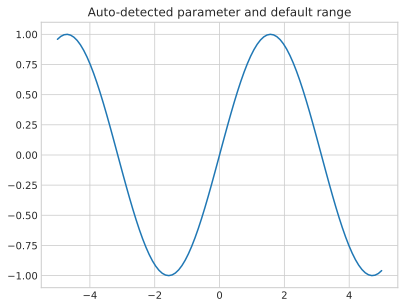

In [3]:
#| code-fold: false
#| classes: size-80
x = sp.Symbol('x')

# Auto-detection with default range [-5, 5]
fplot(sp.sin(x))
plt.title('Auto-detected parameter and default range')
plt.grid(True)
plt.show()

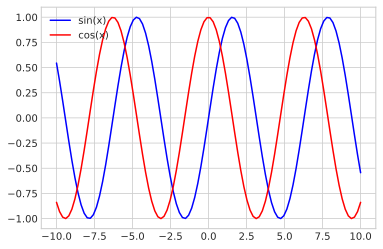

In [4]:
# | code-fold: false
#| classes: size-80
# Custom range and multiple functions
fig, ax = plt.subplots(figsize=(6, 4))
fplot(sp.sin(x), range=(-10, 10), ax=ax, color='blue', label='sin(x)')
fplot(sp.cos(x), range=(-10, 10), ax=ax, color='red', label='cos(x)')
ax.legend()
ax.grid(True)
plt.show()

## Parametric Curves

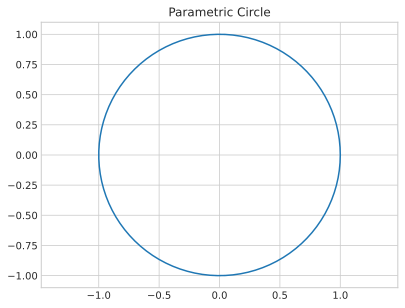

In [5]:
# | code-fold: false
#| classes: size-80
t = sp.Symbol('t')

# Circle
fplot(sp.cos(t), sp.sin(t), range=(0, 2*np.pi))
plt.axis('equal')
plt.title('Parametric Circle')
plt.grid(True)
plt.show()

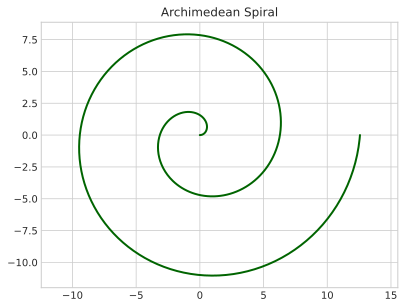

In [6]:
# | code-fold: false
#| classes: size-80
# Spiral with higher resolution
fplot(t*sp.cos(t), t*sp.sin(t), range=(0, 4*np.pi), 
      color='darkgreen', linewidth=2, npoints=500)
plt.axis('equal')
plt.title('Archimedean Spiral')
plt.grid(True)
plt.show()

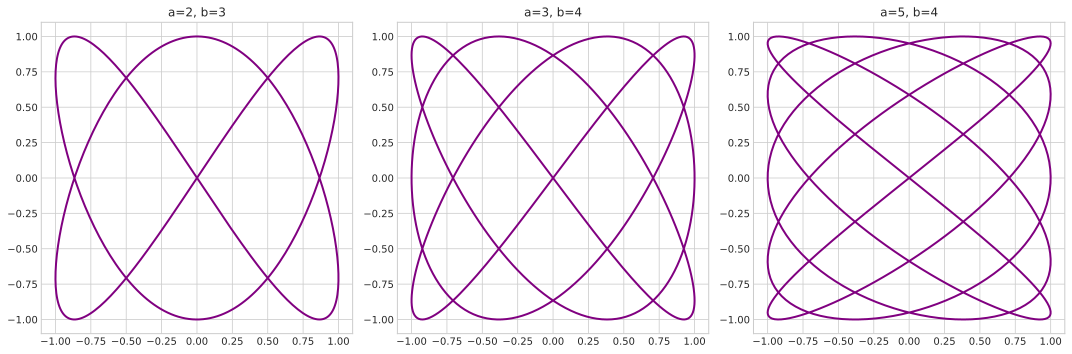

In [7]:
# | code-fold: false
#| classes: size-100

# Lissajous curves

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (a, b) in enumerate([(2, 3), (3, 4), (5, 4)]):
    ax = axes[idx]
    fplot(sp.sin(a*t), sp.sin(b*t), range=(0, 2*np.pi), 
          ax=ax, color='purple', linewidth=2, npoints=500)
    ax.set_aspect('equal')
    ax.set_title(f'a={a}, b={b}')
    ax.grid(True)

plt.tight_layout()
plt.show()

## Engineering Applications

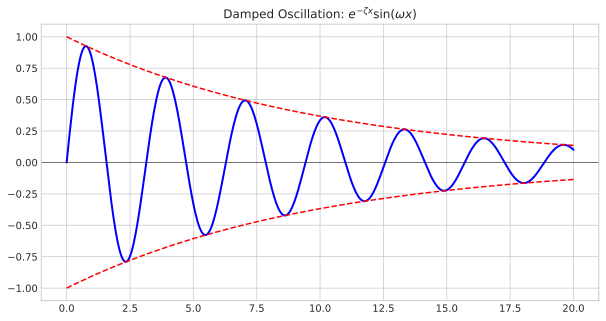

In [8]:
#| code-fold: false
#| classes: size-100
# Damped oscillation
omega, zeta = 2, 0.1
fig, ax = plt.subplots(figsize=(10, 5))

fplot(sp.exp(-zeta*x)*sp.sin(omega*x), range=(0, 20), 
      ax=ax, color='blue', linewidth=2, npoints=500)
fplot(sp.exp(-zeta*x), range=(0, 20), 
      ax=ax, color='red', linestyle='--', label='Envelope')
fplot(-sp.exp(-zeta*x), range=(0, 20), 
      ax=ax, color='red', linestyle='--')

ax.set_title(r'Damped Oscillation: $e^{-\zeta x}\sin(\omega x)$')
ax.grid(True)
ax.axhline(0, color='k', linewidth=0.5)
plt.show()